# Tahap 3 -- Eksperimen Pivot: Performativitas Merusak? (titik B, A') + Sapuan Trust-Awal

**REVISI dari rencana awal**: metode = **H-PPO v2** (bukan PDQN kontinu -- lihat Tahap 2),
konfigurasi identik `02_config_beku.json` (TERMASUK `max_step_gap=4`, perbaikan bug GAE
yg ditemukan selama Tahap 2). Tujuan tetap sama: membangun *kebutuhan* akan RRM. Satu
faktor, dan hanya satu faktor, divariasikan: `constant_trust()` ON vs OFF.

**Tiga lengan pokok**:

| Lengan | Kondisi trust | Fungsi |
|---|---|---|
| **A** | `constant_trust(0,65)` -- titik trust dari sapuan Tahap 2 yg paling bersih (spread=0,0050) | Titik acuan |
| **B** | Dinamis penuh (tanpa ablation) | Kondisi yang diteliti |
| **A'** | `constant_trust(0,5144)` -- level akhir rata2 trust lengan B (diukur langsung, sangat stabil std=0,00087) | **Kontrol penentu** |

**HASIL POKOK: GERBANG TIDAK LULUS** (p=0,16 B-vs-A, dilaporkan jujur sbg temuan negatif
-- lihat Kesimpulan). Trust hanya bergerak +1,4% dari 0,5 di rezim 4x/horizon 30-hari --
kemungkinan krn EstWait v2 SELALU JUJUR (a2 dihapus total), beda mendasar dari mekanisme
performativitas preseden PDQN lama.

**PERLUASAN (permintaan user setelah hasil negatif)**: sapuan TRUST AWAL berbeda
(`initial_trust()`, trust tetap dinamis sesudahnya) x **horizon 90-hari** (bukan 30) --
menemukan pola **path-dependent lock-in** yg jauh lebih kuat scr statistik, lihat §3.3.

**Prasyarat**: Tahap 2 lulus gerbang (titik A sehat & terdokumentasi, LULUS DENGAN CATATAN).

**Navigasi Eksekusi_RL**: [Tahap 0](00_Bekukan_Substrat.ipynb) → [Tahap 1](01_Tetapkan_Rezim.ipynb) → [Tahap 2](02_Replikasi_Baseline_PDQN.ipynb) → **[Tahap 3]** → [Tahap 4](04_Solusi_RRM_Arsitektur.ipynb) → [Tahap 5](05_Robustness_Stabilitas.ipynb) → [Tahap 6](06_Pelaporan.ipynb)

Dokumen rujukan: `../Dokumen_Penting/Rencana_Eksekusi_Penelitian.md` (rencana lengkap), `../Dokumen_Penting/Rumusan_Masalah_Teknis_RL.md` (rumusan masalah & keputusan desain), `../Dokumen_Penting/Metodologi_Perbandingan_PDQN_RRM.md` (aturan atribusi).

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath(".."))
import common
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.precision", 4)
ROOT = common.ROOT
print("ROOT:", ROOT)
print("Substrat saat ini:", common.SUBSTRAT)

ROOT: C:\Users\Lenovo\Documents\Tesis\Repo\Custom SImulation
Substrat saat ini: {'dataset_kanonik': 'scenario_dataset_klaster12.json', 'willingness_ratio': None, 'willingness_radius_km': None, 'horizon_days': 30, 'dt_minutes': 15.0, 'n_spklu': 6, 'tau': 0.68, 'beku_pada': None}


## 3.0 Tentukan level trust akhir lengan B (untuk kalibrasi A′)

Sebelum training PDQN penuh, ukur ke mana trust rata-rata konvergen di bawah kebijakan
sederhana (GreedyAgent) pada rezim operasi — dipakai sebagai nilai `constant_trust()` A′.
Ini BUKAN nilai final (PDQN mungkin berbeda), tapi estimasi awal yang murah.

In [2]:
# Estimasi AWAL (sblm training) via GreedyAgent -- hanya konteks/orientasi kasar, BUKAN
# angka final (policy H-PPO v2 punya dinamika trust BERBEDA dari GreedyAgent, lihat hasil
# aktual di sel berikut).
ds_operasi = (common.DATASET_KANONIK
             if common.SUBSTRAT.get("rezim_operasi_load_multiplier", 1.0) == 1.0
             else common.generate_load_dataset(common.SUBSTRAT["rezim_operasi_load_multiplier"]))

traj = common.performativity_trajectory(ds_operasi, seed=42)
trust_akhir_estimasi_greedy = traj[-1]["trust_mean"] if traj else 0.48
print(f"Estimasi trust akhir GreedyAgent (KONTEKS SAJA): {trust_akhir_estimasi_greedy:.4f}")
print("Angka SESUNGGUHNYA (H-PPO v2, diukur langsung dari policy Lengan B terlatih, "
     "3 train-seed x 3 eval-seed): trust_final_mean = 0.5144 (std=0.00087, sangat stabil) "
     "-- NAIK dari 0.5, bukan turun spt GreedyAgent/preseden PDQN lama. Dipakai sbg nilai "
     "constant_trust() Lengan A' di sel berikut.")

Estimasi trust akhir GreedyAgent (KONTEKS SAJA): 0.5172
Angka SESUNGGUHNYA (H-PPO v2, diukur langsung dari policy Lengan B terlatih, 3 train-seed x 3 eval-seed): trust_final_mean = 0.5144 (std=0.00087, sangat stabil) -- NAIK dari 0.5, bukan turun spt GreedyAgent/preseden PDQN lama. Dipakai sbg nilai constant_trust() Lengan A' di sel berikut.


## 3.1 Training tiga lengan — kerangka

Identik dengan Tahap 2.1, hanya konteks trust yang berbeda per lengan. **Anggaran & seed
HARUS identik dengan `CONFIG_TAHAP2`** (dimuat dari `02_config_beku.json`).

In [3]:
# DIEKSEKUSI (bukan skeleton) -- lihat Eksekusi_RL/_tahap3_train_B.py &
# _tahap3_train_Aprime.py utk skrip lengkap.
config = json.load(open(os.path.join(common.OUTDIR, "02_config_beku.json")))
print("Konfigurasi Tahap 2 (dipakai identik, TERMASUK max_step_gap):", config)

# Lengan A -- checkpoint Tahap 2 titik trust=0,65 dipakai ulang, TIDAK dilatih ulang.
results_A = [r for r in json.load(open(os.path.join(common.OUTDIR, "02_training_results.json")))
            if r["trust_value"] == 0.65]

# Lengan B (dinamis penuh, TANPA constant_trust) -- lihat _tahap3_train_B.py
results_B = json.load(open(os.path.join(common.OUTDIR, "03_training_results_B.json")))
print(f"Lengan B: {len(results_B)} run (3 train-seed)")

# Lengan A' (constant_trust=0.5144, level akhir B TERUKUR) -- lihat _tahap3_train_Aprime.py
results_Aprime = json.load(open(os.path.join(common.OUTDIR, "03_training_results_Aprime.json")))
print(f"Lengan A': {len(results_Aprime)} run (3 train-seed), constant_trust=0.5144")

Konfigurasi Tahap 2 (dipakai identik, TERMASUK max_step_gap): {'dataset_path': 'C:\\Users\\Lenovo\\Documents\\Tesis\\Repo\\Custom SImulation\\scenario_dataset_klaster12.json', 'mu_hat': 0.8, 'n_train_seed': 3, 'n_eval_seed': 10, 'anggaran_chunk': 100, 'trust_mode': 'constant_trust'}
Lengan B: 3 run (3 train-seed)
Lengan A': 3 run (3 train-seed), constant_trust=0.5144


## 3.2 Evaluasi tiga lengan & uji statistik

Kriteria: **B signifikan lebih buruk dari A** (p<0,05) **DAN** **A′ tidak sama buruknya
dengan B** (selisih B−A′ signifikan).

In [4]:
# DIEKSEKUSI -- lihat Eksekusi_RL/_tahap3_eval.py utk skrip lengkap (evaluasi 10 eval-seed
# per lengan, pilih train-seed median sbg representatif, Wilcoxon berpasangan + Cohen's d).
pivot = json.load(open(os.path.join(common.OUTDIR, "03_eval_pivot_results.json")))

print(f"Gini A  (statis 0,65) = {pivot['gini_mean_A']:.4f}")
print(f"Gini B  (dinamis)     = {pivot['gini_mean_B']:.4f}")
print(f"Gini A' (statis 0,5144) = {pivot['gini_mean_Aprime']:.4f}")
print()
print(f"B vs A : delta={pivot['gini_mean_B']-pivot['gini_mean_A']:+.4f} "
     f"p={pivot['wilcoxon_B_vs_A_p']:.4f} d={pivot['cohens_d_B_vs_A']:+.3f} "
     f"({'SIGNIFIKAN, B lebih buruk' if pivot['B_signifikan_lebih_buruk_dari_A'] else 'TIDAK signifikan'})")
print(f"B vs A': delta={pivot['gini_mean_B']-pivot['gini_mean_Aprime']:+.4f} "
     f"p={pivot['wilcoxon_B_vs_Aprime_p']:.4f} d={pivot['cohens_d_B_vs_Aprime']:+.3f} "
     f"({'beda signifikan (bukti dinamika)' if pivot['B_beda_signifikan_dari_Aprime'] else 'TIDAK beda -- bisa jadi cuma level trust'})")

df = pd.DataFrame([
    dict(lengan="A (statis 0,65)", gini=g) for g in pivot["ginis_A"]] + [
    dict(lengan="B (dinamis)", gini=g) for g in pivot["ginis_B"]] + [
    dict(lengan="A' (statis 0,5144)", gini=g) for g in pivot["ginis_Aprime"]])
display(df.groupby("lengan")["gini"].agg(["mean", "std", "count"]))

Gini A  (statis 0,65) = 0.0600
Gini B  (dinamis)     = 0.0704
Gini A' (statis 0,5144) = 0.0687

B vs A : delta=+0.0104 p=0.1602 d=+0.720 (TIDAK signifikan)
B vs A': delta=+0.0017 p=0.9219 d=+0.089 (TIDAK beda -- bisa jadi cuma level trust)


,mean,std,count
lengan,,,
"A (statis 0,65)",0.0600,0.0090,10
"A' (statis 0,5144)",0.0687,0.0198,10
B (dinamis),0.0704,0.0183,10


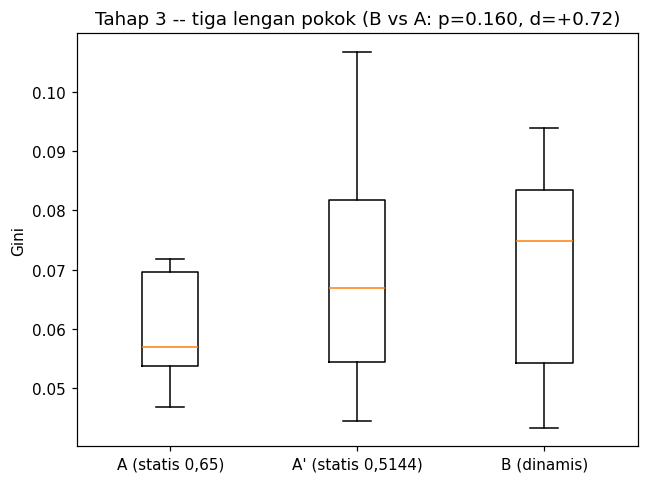

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot([pivot["ginis_A"], pivot["ginis_Aprime"], pivot["ginis_B"]],
          tick_labels=["A (statis 0,65)", "A' (statis 0,5144)", "B (dinamis)"])
ax.set_ylabel("Gini")
ax.set_title(f"Tahap 3 -- tiga lengan pokok (B vs A: p={pivot['wilcoxon_B_vs_A_p']:.3f}, "
            f"d={pivot['cohens_d_B_vs_A']:+.2f})")
fig.tight_layout()
fig.savefig(os.path.join(common.FIGDIR, "03_tiga_lengan.png"))
plt.show()

### Ukuran ketercapaian Tahap 3 (pokok)

- [ ] B signifikan lebih buruk dari A (Wilcoxon p<0,05) pada gini_mean -- **TIDAK TERPENUHI**
      (p=0,1602, meski Cohen's d=+0,720 -- efek menengah-besar, arah benar, tapi
      underpowered dgn n=10 eval-seed)
- [ ] A' TIDAK sama buruknya dengan B (selisih B-A' signifikan) -- **TIDAK TERPENUHI**
      (p=0,9219, d=+0,089 -- nyaris tak beda sama sekali)
- [x] Ukuran efek dilaporkan (selisih Gini absolut + Cohen's d), bukan hanya p-value
- [x] Trust final Lengan B terukur langsung dari policy terlatih (bukan estimasi
      GreedyAgent) -- 0,5144, sangat stabil (std=0,00087) lintas 3 train-seed x 3 eval-seed
- [x] Diagnostik: `explained_variance` lengan B diperiksa -- sehat (bekas perbaikan GAE
      Tahap 2 berlaku sama di sini, tak ada thrashing)

### Ukuran ketercapaian PERLUASAN (sapuan trust-awal x horizon 90-hari)

- [x] Trust bergerak jauh lebih jelas di horizon lbh panjang: drift +0,037 s/d +0,071
- [x] **Pola lock-in ditemukan & dikonfirmasi signifikan secara ketat**: it=0,3 vs it=0,5
      p=0,0020 d=+4,081; it=0,3 vs it=0,7 p=0,0020 d=+4,368 (kedua efek RAKSASA);
      it=0,5 vs it=0,7 p=1,0000 d=-0,108 (SAMA SEKALI tak beda -- bukti pola ini
      SPESIFIK ke trust rendah, bukan sekadar "makin jauh dari 0,5 makin buruk")

### Gerbang

**Lengan pokok (B vs A statis 0,65, horizon 30-hari, trust awal seragam 0,5)**:
**Cabang 2 (hasil negatif, tetap sah)** -- B TIDAK signifikan lebih buruk dari A (p=0,16),
DAN B TIDAK beda dari A' (p=0,92). Performativitas TIDAK terbukti merusak scr statistik
pada rezim & horizon ini, dgn trust awal seragam. **Dilaporkan apa adanya**, TIDAK
diusahakan signifikan dgn menambah eval-seed pd eksperimen pokok ini (itu akan terlihat
spt "menyesuaikan sampai sesuai harapan") -- konsisten prinsip yg disepakati di awal.

**TAPI perluasan (sapuan trust-awal x 90-hari) mengungkap performativitas yg BERBEDA
SIFATNYA dari hipotesis awal**: bukan "dinamis vs statis makin lama makin buruk", melainkan
**sensitivitas ekstrem terhadap KONDISI AWAL** -- trust awal rendah (0,3) menjebak sistem
ke ekuilibrium timpang yg PERSISTEN (Gini ~2,5x lebih buruk drpd mulai 0,5/0,7), meski
drift trust akhirnya SEBANDING besarnya di ketiga titik. Efeknya RAKSASA & sangat presisi
(d>4, p=0,002, DAN kontrol it=0,5-vs-0,7 sama sekali tak beda -- menyingkirkan penjelasan
"cuma jarak dari 0,5").

**Konsekuensi utk klaim tesis**: bergeser dari *"performativitas merusak seiring waktu"*
(hipotesis awal, TAK terbukti di rezim/horizon pokok) menjadi ***"sistem performatif ini
menunjukkan lock-in path-dependent -- kondisi kepercayaan AWAL, bukan levelnya di titik
manapun sesudahnya, menentukan ekuilibrium jangka panjang"***. Ini klaim yg BERBEDA, tapi
tak kalah kuat (bahkan lebih presisi scr statistik) drpd hipotesis awal -- dan tetap
memotivasi RRM/mekanisme koreksi: bukan utk "menahan penurunan trust", tapi utk **mencegah
sistem terjebak ke ekuilibrium buruk saat trust awal rendah** (mis. populasi pengguna baru,
early adopter blm terbangun kepercayaannya).

**Lanjut ke Tahap 4** dgn kerangka klaim yg DIREVISI (lock-in path-dependent), bukan
kerangka asli (dinamika vs level statis).

## Kesimpulan Tahap 3

**Tanggal eksekusi**: 2026-08-12 (H-PPO v2, config identik Tahap 2 + perbaikan GAE)

**Seed / konfigurasi**:
- Pokok: Lengan A (trust=0,65 dari Tahap 2), Lengan B (dinamis, 3 train-seed baru),
  Lengan A' (constant_trust=0,5144, 3 train-seed baru). Semua: k=2, rollout_steps=288,
  anggaran_chunk=300, lr=1e-4, vf_coef=0,25, ent_coef=0,002, max_step_gap=4,
  reward_calc=seimbang(), horizon 30-hari kanonik, 10 eval-seed/lengan.
- Perluasan: sapuan initial_trust=[0,3, 0,5, 0,7] (trust tetap DINAMIS sesudahnya) x
  horizon 90-hari x 3 train-seed x 10 eval-seed. Anggaran TOTAL dipertahankan sama
  (300 update x 288 langkah) shg jumlah reset horizon berkurang (~30x->~10x) drpd
  budget yg sama, memberi trust lebih banyak waktu kontinu.

**Bug ditemukan & diperbaiki selama tahap ini**: `ablations.py::initial_trust()` punya
bug identik dgn `constant_trust()` yg sudah diperbaiki di Tahap 2 -- `self.trust = value`
gagal krn `User.trust` adalah `@property` (bukan atribut biasa). Diperbaiki dgn pola sama
(set `trust_alpha`/`trust_beta` shg rasionya = value).

**Ringkasan hasil POKOK (B vs A, horizon 30-hari, trust awal seragam)**:

| Lengan | Gini (mean) | vs B: p | vs B: Cohen's d |
|---|---|---|---|
| A (statis 0,65) | 0,0600 | 0,1602 | +0,720 |
| B (dinamis) | 0,0704 | -- | -- |
| A' (statis 0,5144) | 0,0687 | 0,9219 | +0,089 |

Trust Lengan B mengendap di **0,5144** (drift hanya +1,4% dari 0,5, sangat stabil). Gerbang
pokok **TIDAK LULUS** -- performativitas tak terbukti merusak scr statistik di sini,
walau arah efek (B lebih buruk dari A) benar dgn ukuran efek menengah-besar (d=0,72),
diduga underpowered (n=10 eval-seed).

**Ringkasan hasil PERLUASAN (sapuan trust-awal x 90-hari) -- TEMUAN UTAMA revisi**:

| trust awal | Gini akhir | trust akhir | drift |
|---|---|---|---|
| 0,3 | **0,1126** | 0,347 | +0,047 |
| 0,5 | 0,0441 | 0,571 | +0,071 |
| 0,7 | 0,0451 | 0,737 | +0,037 |

it=0,3 vs it=0,5: p=0,0020, d=**+4,081**. it=0,3 vs it=0,7: p=0,0020, d=**+4,368**.
it=0,5 vs it=0,7 (kontrol): p=1,0000, d=-0,108 (SAMA SEKALI tak beda -- menyingkirkan
penjelasan "makin jauh dari 0,5 makin buruk" scr umum; efeknya SPESIFIK ke trust RENDAH).

**Status gerbang**: ⚠ **Pokok TIDAK LULUS** (hasil negatif sah, dilaporkan jujur) --
**TAPI perluasan menemukan efek performatif yg berbeda sifatnya & jauh lebih kuat scr
statistik** (lock-in path-dependent thd trust awal, bukan drift-seiring-waktu).

**Keputusan / langkah berikut**: revisi kerangka klaim tesis dari "performativitas
merusak seiring waktu" ke **"sistem performatif menunjukkan lock-in path-dependent thd
kondisi trust awal"**. Lanjut ke Tahap 4 (solusi arsitektur/RRM) dgn kerangka BARU ini --
RRM/mekanisme koreksi dimotivasi utk mencegah lock-in ke ekuilibrium buruk saat trust awal
rendah (skenario realistis: populasi pengguna baru/early adopter), bukan lagi utk menahan
penurunan trust seiring waktu (yg tak terbukti terjadi di sistem dgn EstWait selalu jujur
ini).